In [1]:
!nvcc --version


nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


In [37]:
%%writefile vectoradd.cu
#include <iostream>
#include <cuda_runtime.h>
#include <chrono>

using namespace std;

#define N 1000000

// GPU Kernel
__global__ void vectorAdd(int *A, int *B, int *C)
{
    int i = blockIdx.x * blockDim.x + threadIdx.x;

    if(i < N)
        C[i] = A[i] + B[i];
}

// CPU Function
void cpuAdd(int *A, int *B, int *C)
{
    for(int i=0;i<N;i++)
        C[i] = A[i] + B[i];
}

int main()
{
    int *A,*B,*C;
    int *dA,*dB,*dC;

    size_t size = N * sizeof(int);

    // allocate host memory
    A = (int*)malloc(size);
    B = (int*)malloc(size);
    C = (int*)malloc(size);

    for(int i=0;i<N;i++)
    {
        A[i] = 1;
        B[i] = 2;
    }

    // CPU timing
    auto start = chrono::high_resolution_clock::now();
    cpuAdd(A,B,C);
    auto end = chrono::high_resolution_clock::now();

    chrono::duration<double> cpu_time = end-start;

    cout<<"CPU Time : "<<cpu_time.count()<<" millisec"<<endl;

    // GPU memory allocation
    cudaMalloc(&dA,size);
    cudaMalloc(&dB,size);
    cudaMalloc(&dC,size);

    cudaMemcpy(dA,A,size,cudaMemcpyHostToDevice);
    cudaMemcpy(dB,B,size,cudaMemcpyHostToDevice);

    auto gstart = chrono::high_resolution_clock::now();

    vectorAdd<<<(N+255)/256,256>>>(dA,dB,dC);

    cudaDeviceSynchronize();

    auto gend = chrono::high_resolution_clock::now();

    chrono::duration<double> gpu_time = gend-gstart;

    cout<<"GPU Time : "<<gpu_time.count()<<" millisec"<<endl;

    cudaMemcpy(C,dC,size,cudaMemcpyDeviceToHost);

    cudaFree(dA);
    cudaFree(dB);
    cudaFree(dC);

    free(A);
    free(B);
    free(C);

    return 0;
}

Overwriting vectoradd.cu


In [38]:
!nvcc vectoradd.cu -o vectoradd

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


In [39]:
!./vectoradd

CPU Time : 0.00740596 millisec
GPU Time : 0.000259591 millisec


CPU Time: 0.00593904
GPU Time: 0.0849453
Observed Speedup: 0.0699160518592553


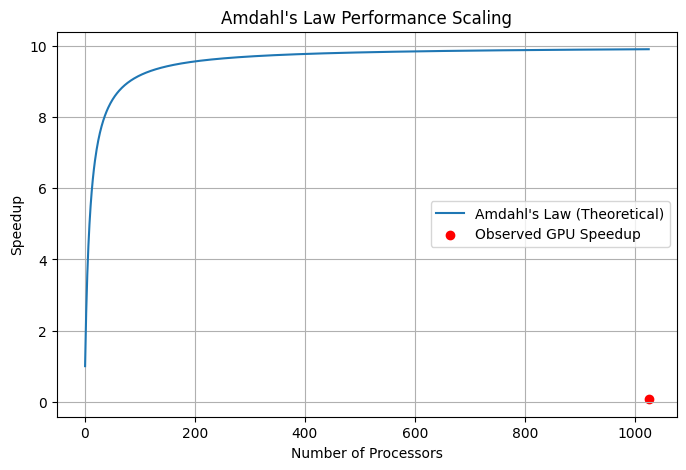

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# Your measured times
cpu_time = 0.00593904
gpu_time = 0.0849453

# Observed speedup
observed_speedup = cpu_time / gpu_time

print("CPU Time:", cpu_time)
print("GPU Time:", gpu_time)
print("Observed Speedup:", observed_speedup)

# Assume parallel portion (P)
P = 0.90

# Number of processors
processors = np.arange(1,1025)

# Amdahl's Law formula
speedup = 1 / ((1-P) + (P/processors))

# Plot
plt.figure(figsize=(8,5))

plt.plot(processors, speedup, label="Amdahl's Law (Theoretical)")
plt.scatter([1024],[observed_speedup],color='red',label="Observed GPU Speedup")

plt.xlabel("Number of Processors")
plt.ylabel("Speedup")
plt.title("Amdahl's Law Performance Scaling")

plt.legend()
plt.grid(True)

plt.show()

In [33]:
%%writefile matrmul.cu
#include <iostream>
#include <cuda_runtime.h>

using namespace std;

#define N 1024

// GPU kernel
__global__ void matMul(int *A,int *B,int *C,int n)
{
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;

    if(row < n && col < n)
    {
        int sum = 0;
        for(int k = 0; k < n; k++)
            sum += A[row*n + k] * B[k*n + col];
        C[row*n + col] = sum;
    }
}

int main()
{
    int *A,*B,*C;
    int *dA,*dB,*dC;

    size_t size = N*N*sizeof(int);

    A = (int*)malloc(size);
    B = (int*)malloc(size);
    C = (int*)malloc(size);

    for(int i = 0; i < N*N; i++)
    {
        A[i] = 1;
        B[i] = 2;
    }

    cudaMalloc(&dA,size);
    cudaMalloc(&dB,size);
    cudaMalloc(&dC,size);

    cudaMemcpy(dA,A,size,cudaMemcpyHostToDevice);
    cudaMemcpy(dB,B,size,cudaMemcpyHostToDevice);

    dim3 threads(16,16);
    dim3 blocks(N/16, N/16);

    // Create CUDA events
    cudaEvent_t start, stop;
    cudaEventCreate(&start);
    cudaEventCreate(&stop);

    // Record start event
    cudaEventRecord(start);

    // Launch kernel
    matMul<<<blocks,threads>>>(dA,dB,dC,N);

    // Record stop event
    cudaEventRecord(stop);

    // Wait for the stop event to complete
    cudaEventSynchronize(stop);

    float milliseconds = 0;
    cudaEventElapsedTime(&milliseconds, start, stop);

    // Copy result back to host
    cudaMemcpy(C,dC,size,cudaMemcpyDeviceToHost);

    cout << "Matrix multiplication completed" << endl;
    cout << "GPU execution time: " << milliseconds << " ms" << endl;

    cudaFree(dA);
    cudaFree(dB);
    cudaFree(dC);

    free(A);
    free(B);
    free(C);

    // Destroy events
    cudaEventDestroy(start);
    cudaEventDestroy(stop);

    return 0;
}

Writing matrmul.cu


In [34]:
!nvcc matrmul.cu -o matrmul

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


In [35]:
!./matrmul

Matrix multiplication completed
GPU execution time: 25.2108 ms
